# ModelObsCompare — Python quickstart (Phase 1)

Python-native reading and plotting of **observed** glacier velocities:

- gridded Sentinel/CSK velocity subsets (`.nc`, read via `h5py` — no `netCDF4` needed)
- per-glacier flowline files (`.mat`, read via `scipy`)

Model (ISSM) export + mesh interpolation are **Phase 2** — see `README.md`.

> Paths live in `moc_py/config.py`. Edit `mp.CONFIG` here to point elsewhere for a session.

In [1]:
# For interactive ROI drawing use the widget backend (needs ipympl):
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import moc_py as mp
print("obs_netcdf_dir  :", mp.CONFIG.obs_netcdf_dir)
print("obs_flowline_dir:", mp.CONFIG.obs_flowline_dir)

obs_netcdf_dir  : /Users/michalea/jupyter/code
obs_flowline_dir: /Users/michalea/Documents/GIMP_Working/RECALC_discharge/redrawn_Jan25


## 1. Gridded observed velocity

In [2]:
O = mp.load_obs_netcdf("Sentinel_Subset_Upernavik.nc", bands=["vv", "vx", "vy"],
                       trange=(2018, 2020))
O

<xarray.Dataset> Size: 91MB
Dimensions:  (y: 256, x: 246, time: 121)
Coordinates:
  * y        (y) float64 2kB -1.809e+06 -1.809e+06 ... -1.86e+06 -1.86e+06
  * x        (x) float64 2kB -3.16e+05 -3.158e+05 ... -2.672e+05 -2.67e+05
  * time     (time) float64 968B 2.018e+03 2.018e+03 ... 2.02e+03 2.02e+03
    time_dt  (time) datetime64[s] 968B 2018-01-05T12:00:00 ... 2019-12-26T12:...
Data variables:
    vv       (y, x, time) float32 30MB -1.0 -1.0 -1.0 ... 216.7 240.6 270.6
    vx       (y, x, time) float32 30MB nan nan nan ... -214.6 -225.9 -225.9
    vy       (y, x, time) float32 30MB nan nan nan 7.64 ... 30.21 82.68 149.0
Attributes:
    epsg:          3413
    geotransform:  -316100.0 200.0 0.0 -1808900.0 0.0 -200.0
    file:          /Users/michalea/jupyter/code/Sentinel_Subset_Upernavik.nc
    bands:         vv,vx,vy

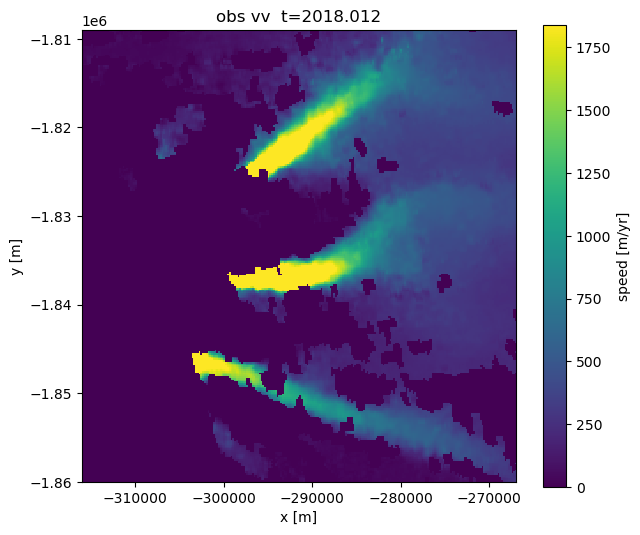

In [3]:
# a single speed frame
mp.plot_map(O, band="vv", tindex=0)
plt.show()

## 2. Region of interest

Derive one from the grid extent, or draw it interactively.

```python
# %matplotlib widget    # enable first, then:
sel = mp.RoiSelector(O, band="vv", tindex=0, kind="rectangle", name="upernavik")
# drag on the figure, then:
roi = sel.save()
```

In [ ]:
roi = mp.roi_from_obs(O, margin=2000, name="upernavik_box")
print("bbox:", tuple(round(b) for b in roi.bbox))

# subset the grid to the ROI (xarray .sel on projected coords)
xmin, xmax, ymin, ymax = roi.bbox
Osub = O.sel(x=slice(xmin, xmax), y=slice(O.y.max(), O.y.min()))  # y is descending
mp.plot_map(Osub, band="vv", tindex=0, roi=roi)
plt.show()

## 3. Observed flowline time series

In [ ]:
F = mp.load_obs_flowline("jakobshavn.mat")   # or "tracy.mat"; or source="SentinelV"
F

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
mp.plot_flowline(F, mode="profile", time=2019.0, ax=axs[0])
mp.plot_flowline(F, mode="hovmoller", ax=axs[1])
plt.tight_layout(); plt.show()

In [ ]:
# time series at a chosen along-flowline distance (5 km up-glacier)
mp.plot_timeseries(F, dist=5000, use_datetime=True)
plt.show()

## 4. Point time series from the gridded product

Compare the same location straight from the netCDF (nearest pixel).

In [ ]:
px, py = float(F.x.isel(point=20)), float(F.y.isel(point=20))
pix = O.sel(x=px, y=py, method="nearest")
plt.figure(figsize=(8, 4))
plt.plot(pix.time_dt, pix.vv, "o-", ms=3)
plt.xlabel("date"); plt.ylabel("speed [m/yr]")
plt.title(f"gridded obs at ({px:.0f}, {py:.0f})"); plt.grid(alpha=0.3)
plt.show()

## 5. Lazy / cloud reads (optional)

`load_obs_netcdf` reads the whole file into memory. For remote/cloud sources, or
to wrap an already-lazy array (e.g. GrIMP `myVelSeries.vv` from the Flowlines
notebook), use `open_obs_dataarray` → a lazy `xarray.DataArray` in moc_py
conventions. Needs the `[lazy]` extras (dask, rioxarray, zarr, h5netcdf).

```python
# from an already-lazy DataArray (dims time,y,x; datetime time):
da = mp.open_obs_dataarray(myVelSeries.vv, band="vv")   # -> (y,x,time), lazy
O  = mp.to_obs_dataset(da)          # obs Dataset; downstream fns compute only what they touch

# or open a remote source directly:
da = mp.open_obs_dataarray("https://.../cube.zarr", band="v", chunks="auto")
da = mp.open_obs_dataarray("s3://bucket/vv_*.tif", band="vv")
```

## Next (Phase 2)

Add `moc_export_model.m` (MATLAB → netCDF: mesh `x,y,elements`, `time`, `vx/vy/vel`)
and `moc_py.model` to load it + interpolate with `matplotlib.tri.LinearTriInterpolator`
for spatial-difference maps and modelled flowline overlays. The plotting functions
here already accept an optional `model=` argument for that.